# The Fourier Transform — From Continuous Integral to DFT to FFT

The continuous Fourier transform measures *how much* of each frequency $f$ lives in a signal by correlating it against a complex exponential and integrating over all time:

$$X(f) = \int_{-\infty}^{+\infty} x(t)\,e^{-j2\pi f t}\,dt \qquad\xrightarrow{\;\text{sample } N \text{ points}\;}\qquad X[k] = \sum_{n=0}^{N-1} x[n]\,e^{-j2\pi kn/N}$$

The exponential $e^{-j2\pi f t}$ is a unit vector spinning clockwise at frequency $f$. **The whole transform is one geometric act: wrap the signal around the unit circle at test-frequency $f$, then find the centre of mass of the wrapped points.** When $f$ matches a frequency present in the signal, the points pile up on one side and the centre of mass is large; otherwise they spread evenly and cancel. Everything below makes that picture explicit, then shows why the FFT computes the same thing thousands of times faster.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
%matplotlib inline

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 100, 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 12,
})

C_SIG, C_RE, C_IM, C_MAG, C_COM, C_WRAP = (
    'steelblue', '#d62728', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd')

def dft_manual(x):
    # Direct O(N^2) DFT — the literal sum, for comparison with FFT
    N = len(x)
    n = np.arange(N)
    k = n.reshape(-1, 1)
    return (x * np.exp(-2j * np.pi * k * n / N)).sum(axis=1)

x_test = np.random.default_rng(0).standard_normal(16)
print('Manual DFT == np.fft.fft :', np.allclose(dft_manual(x_test), np.fft.fft(x_test)))

Manual DFT == np.fft.fft : True


## The Continuous Transform as Correlation

$X(f)$ at a single frequency is the area under the product of the signal and a complex sinusoid. Split into real and imaginary parts, it correlates the signal against a cosine and a sine:

$$X(f) = \underbrace{\int x(t)\cos(2\pi f t)\,dt}_{\Re\{X\}} \; - \; j\underbrace{\int x(t)\sin(2\pi f t)\,dt}_{\Im\{X\}}$$

For a finite record we approximate the integral numerically. Slide the **test frequency** and watch the product $x(t)\cos(2\pi f t)$: when $f$ hits a tone in the signal the product stops oscillating around zero and develops net area — that area *is* the transform value.

In [ ]:
def show_correlation(f_test):
    T, fs = 2.0, 600.0
    t = np.linspace(0, T, int(T * fs), endpoint=False)
    sig = np.cos(2 * np.pi * 4 * t) + 0.6 * np.cos(2 * np.pi * 9 * t)

    prod_re = sig * np.cos(2 * np.pi * f_test * t)
    prod_im = sig * np.sin(2 * np.pi * f_test * t)
    Xre =  np.trapezoid(prod_re, t)
    Xim = -np.trapezoid(prod_im, t)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(t, sig, color=C_SIG, lw=1, alpha=0.5, label='$x(t)$')
    a1.plot(t, np.cos(2 * np.pi * f_test * t), color=C_RE, lw=1,
            alpha=0.5, label=f'$\\cos(2\\pi\\cdot{f_test:.1f}\\,t)$')
    a1.plot(t, prod_re, color='k', lw=1.4, label='product')
    a1.fill_between(t, prod_re, alpha=0.25, color=C_MAG)
    a1.set_xlabel('Time (s)'); a1.set_ylabel('Amplitude')
    a1.set_title(f'Net area (real part) = {Xre:+.2f}')
    a1.legend(fontsize=8.5, loc='upper right')

    # sweep f to draw the full magnitude spectrum, mark current f_test
    fsweep = np.linspace(0, 15, 400)
    mag = np.array([np.hypot(np.trapezoid(sig * np.cos(2*np.pi*ff*t), t),
                             np.trapezoid(sig * np.sin(2*np.pi*ff*t), t))
                    for ff in fsweep])
    a2.plot(fsweep, mag, color=C_MAG, lw=1.8)
    a2.fill_between(fsweep, mag, alpha=0.2, color=C_MAG)
    a2.axvline(f_test, color=C_RE, lw=1.8, ls='--', label=f'$f$={f_test:.1f} Hz')
    a2.plot(f_test, np.hypot(Xre, Xim), 'o', color=C_RE, ms=9)
    a2.set_xlabel('Frequency (Hz)'); a2.set_ylabel('|X(f)|')
    a2.set_title('Spectrum built by sweeping $f$')
    a2.legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()

ft_w = widgets.FloatSlider(value=4.0, min=0, max=15, step=0.1,
        description='test frequency $f$ (Hz)',
        style={'description_width': '170px'}, layout=widgets.Layout(width='520px'))
display(widgets.VBox([ft_w,
        widgets.interactive_output(show_correlation, {'f_test': ft_w})]))

## Beyond the Formula: Wrapping the Signal Around a Circle

Combine cosine and sine into one complex spinner $e^{-j2\pi f t}$. Multiplying the signal by it **winds the time samples around the origin** at $f$ revolutions per record. The DFT value is exactly $N$ times the **centre of mass** of those wound points:

$$X[k] = \sum_{n=0}^{N-1} x[n]\,e^{-j2\pi kn/N} = N\cdot\underbrace{\frac1N\sum_{n=0}^{N-1} x[n]\,e^{-j2\pi kn/N}}_{\text{centre of mass}}$$

At a wrapping frequency that matches a tone, the points bunch on one side $\Rightarrow$ centre of mass flies out from the origin $\Rightarrow$ large $|X[k]|$. At a mismatched frequency the winding is balanced and the centre of mass sits at the origin. Drag the wrapping frequency through the two tones (at bins 5 and 12) and watch the orange dot.

In [ ]:
def show_wrapping(f_wrap, show_path):
    N = 128
    n = np.arange(N)
    sig = np.cos(2 * np.pi * 5 * n / N) + 0.6 * np.cos(2 * np.pi * 12 * n / N)
    wound = sig * np.exp(-2j * np.pi * f_wrap * n / N)   # points on the plane
    com = wound.mean()                                   # centre of mass

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
    a1.plot(n, sig, color=C_SIG, lw=1.3)
    a1.fill_between(n, sig, alpha=0.15, color=C_SIG)
    a1.set_xlabel('Sample $n$'); a1.set_ylabel('$x[n]$')
    a1.set_title('Signal: tones at bins 5 and 12')

    a2.add_patch(Circle((0, 0), np.max(np.abs(sig)), fill=False,
                        color='gray', lw=0.8, alpha=0.5))
    a2.axhline(0, color='gray', lw=0.6); a2.axvline(0, color='gray', lw=0.6)
    if show_path:
        a2.plot(wound.real, wound.imag, '-', color=C_WRAP, lw=0.7, alpha=0.5)
    a2.scatter(wound.real, wound.imag, c=n, cmap='viridis', s=14, zorder=3)
    a2.plot([0, com.real], [0, com.imag], color=C_COM, lw=2.2, zorder=4)
    a2.plot(com.real, com.imag, 'o', color=C_COM, ms=13, zorder=5,
            label=f'centre of mass  |COM|={np.abs(com):.2f}')
    lim = np.max(np.abs(sig)) * 1.15
    a2.set_xlim(-lim, lim); a2.set_ylim(-lim, lim); a2.set_aspect('equal')
    a2.set_xlabel('Real'); a2.set_ylabel('Imag')
    a2.set_title(f'Wound at $f$={f_wrap:.2f} cycles/record')
    a2.legend(fontsize=9, loc='upper right'); a2.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

fw_w = widgets.FloatSlider(value=5.0, min=0, max=20, step=0.05,
        description='wrapping freq (cycles)',
        style={'description_width': '170px'}, layout=widgets.Layout(width='520px'))
path_w = widgets.Checkbox(value=True, description='show winding path',
        style={'description_width': '170px'})
display(widgets.VBox([widgets.HBox([fw_w, path_w]),
        widgets.interactive_output(show_wrapping,
            {'f_wrap': fw_w, 'show_path': path_w})]))

## Step-by-Step: Building the Spectrum One Bin at a Time

The DFT evaluates that centre-of-mass at the $N$ **integer** wrapping frequencies $k=0,1,\dots,N-1$ — these are the only frequencies that complete a whole number of turns in the record, so they form an orthogonal basis. Step $k$ upward and watch the spectrum fill in bin by bin while the left panel shows the exact winding that produced the current bar:

$$|X[k]| = N\,\bigl|\text{centre of mass at }k\bigr|, \qquad k = 0,1,\dots,N-1$$

The signal here has tones at bins 6 and 17, so only those two integer wrappings (and their conjugate mirrors at $N-6$, $N-17$) produce a non-zero centre of mass.

In [ ]:
def dft_step(k):
    N = 48
    n = np.arange(N)
    sig = (np.cos(2 * np.pi * 6 * n / N)
           + 0.7 * np.cos(2 * np.pi * 17 * n / N + 0.5))
    X = np.fft.fft(sig)
    wound = sig * np.exp(-2j * np.pi * k * n / N)
    com = wound.mean()

    fig = plt.figure(figsize=(13, 4.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.25], wspace=0.28)
    aL, aR = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    aL.axhline(0, color='gray', lw=0.6); aL.axvline(0, color='gray', lw=0.6)
    aL.scatter(wound.real, wound.imag, c=n, cmap='plasma', s=22, zorder=3)
    aL.plot([0, com.real], [0, com.imag], color=C_COM, lw=2.4, zorder=4)
    aL.plot(com.real, com.imag, 'o', color=C_COM, ms=12, zorder=5)
    lim = np.max(np.abs(sig)) * 1.15
    aL.set_xlim(-lim, lim); aL.set_ylim(-lim, lim); aL.set_aspect('equal')
    aL.set_xlabel('Real'); aL.set_ylabel('Imag')
    aL.set_title(f'Wrapping at bin $k$={k}  →  $|X[{k}]|$={np.abs(X[k]):.1f}')
    aL.grid(alpha=0.2)

    mag = np.abs(X)
    bars = aR.bar(np.arange(N), mag, color='lightgray', width=0.85)
    for j in range(k + 1):
        bars[j].set_color(C_MAG)
    bars[k].set_color(C_RE)
    aR.set_xlabel('Bin index $k$'); aR.set_ylabel('$|X[k]|$')
    aR.set_title(f'Spectrum filled up to bin {k} of {N-1}')
    aR.set_xlim(-1, N)
    plt.tight_layout(); plt.show()

k_w = widgets.IntSlider(value=0, min=0, max=47, step=1,
        description='bin $k$ (step me)',
        style={'description_width': '150px'}, layout=widgets.Layout(width='520px'),
        continuous_update=False)
play = widgets.Play(value=0, min=0, max=47, step=1, interval=350)
widgets.jslink((play, 'value'), (k_w, 'value'))
display(widgets.VBox([widgets.HBox([play, k_w]),
        widgets.interactive_output(dft_step, {'k': k_w})]))

## Continuous Transform vs DFT: the Same Shape, Sampled

The DFT is the continuous transform of a **sampled, finite** signal, read at discrete frequencies $f_k = k\,f_s/N$. For a rectangular pulse the continuous transform is a sinc; the DFT lands exactly on samples of that sinc (up to the windowing from the finite record):

$$x(t)=\operatorname{rect}(t/T)\;\Longleftrightarrow\; X(f)=T\,\operatorname{sinc}(fT),\qquad \operatorname{sinc}(u)=\frac{\sin\pi u}{\pi u}$$

Change the pulse width and record length: a **narrower pulse** spreads the sinc wider in frequency (the uncertainty trade-off), and **more samples** pack the DFT dots more densely along the same continuous curve.

In [6]:
def show_bridge(pulse_width, N):
    fs = 64.0
    t = (np.arange(N) - N // 2) / fs
    rect = (np.abs(t) <= pulse_width / 2).astype(float)

    X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rect))) / fs
    fk = np.fft.fftshift(np.fft.fftfreq(N, 1 / fs))

    f_cont = np.linspace(fk.min(), fk.max(), 2000)
    X_cont = pulse_width * np.sinc(f_cont * pulse_width)   # analytic CTFT

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(t, rect, color=C_SIG, lw=1.6, drawstyle='steps-mid')
    a1.fill_between(t, rect, alpha=0.2, color=C_SIG, step='mid')
    a1.set_xlabel('Time (s)'); a1.set_ylabel('$x(t)$')
    a1.set_title(f'Rect pulse, width={pulse_width:.2f} s, {N} samples')

    a2.plot(f_cont, X_cont, color='gray', lw=1.6,
            label='continuous $T\\,\\mathrm{sinc}(fT)$')
    a2.plot(fk, X.real, 'o', color=C_RE, ms=4,
            label='DFT samples')
    a2.axhline(0, color='gray', lw=0.6)
    a2.set_xlim(-12, 12)
    a2.set_xlabel('Frequency (Hz)'); a2.set_ylabel('$X(f)$  (real)')
    a2.set_title('DFT dots sit on the continuous sinc')
    a2.legend(fontsize=9, loc='upper right')
    plt.tight_layout(); plt.show()

pw_w = widgets.FloatSlider(value=0.5, min=0.1, max=1.5, step=0.05,
        description='pulse width (s)',
        style={'description_width': '150px'}, layout=widgets.Layout(width='500px'))
Nb_w = widgets.IntSlider(value=64, min=16, max=256, step=16,
        description='samples $N$',
        style={'description_width': '150px'}, layout=widgets.Layout(width='500px'))
display(widgets.VBox([widgets.HBox([pw_w, Nb_w]),
        widgets.interactive_output(show_bridge,
            {'pulse_width': pw_w, 'N': Nb_w})]))

## The FFT Insight: Why $N^2$ Becomes $N\log_2 N$

The DFT recomputes the same twiddle products over and over. The **Cooley–Tukey FFT** splits the length-$N$ DFT into two length-$N/2$ DFTs — even-indexed and odd-indexed samples — and stitches them with a single twiddle factor per pair:

$$X[k] = \underbrace{E[k]}_{\text{even DFT}} + e^{-j2\pi k/N}\,\underbrace{O[k]}_{\text{odd DFT}},\qquad X[k+\tfrac N2] = E[k] - e^{-j2\pi k/N}\,O[k]$$

Recursing this split $\log_2 N$ times collapses the cost from $N^2$ to $N\log_2 N$. The function below is a literal radix-2 FFT — verify it matches `numpy`, then read the speedup table.

In [7]:
def fft_recursive(x):
    N = len(x)
    if N == 1:
        return x
    E = fft_recursive(x[0::2])           # even-indexed sub-DFT
    O = fft_recursive(x[1::2])           # odd-indexed sub-DFT
    k = np.arange(N // 2)
    tw = np.exp(-2j * np.pi * k / N)     # twiddle factors
    return np.concatenate([E + tw * O, E - tw * O])

xr = np.random.default_rng(1).standard_normal(64)
print('Recursive FFT == np.fft.fft :', np.allclose(fft_recursive(xr), np.fft.fft(xr)))
print()
print(f"{'N':>10} | {'DFT  (N^2)':>20} | {'FFT (N log2 N)':>16} | {'speedup':>10}")
for N in (8, 64, 1024, 65536, 1_048_576):
    dft_ops, fft_ops = N * N, N * np.log2(N)
    print(f'{N:>10,} | {dft_ops:>20,} | {fft_ops:>16,.0f} | {dft_ops / fft_ops:>9,.0f}x')

Recursive FFT == np.fft.fft : True

         N |           DFT  (N^2) |   FFT (N log2 N) |    speedup
         8 |                   64 |               24 |         3x
        64 |                4,096 |              384 |        11x
     1,024 |            1,048,576 |           10,240 |       102x
    65,536 |        4,294,967,296 |        1,048,576 |     4,096x
 1,048,576 |    1,099,511,627,776 |       20,971,520 |    52,429x


## Measuring It: DFT vs FFT Wall-Clock

The asymptotics are not academic — timing the naive $O(N^2)$ DFT against `np.fft.fft` shows the gap widening as a near-straight line on a log-log plot, with slope $\approx 2$ for the DFT and $\approx 1$ for the FFT.

| $N$ | DFT trend | FFT trend |
|:---|:---|:---|
| small | both fast, overhead dominates | both fast |
| $\sim 10^3$ | DFT noticeably slower | flat |
| $\sim 10^4$+ | DFT quadratic blow-up | barely moves |

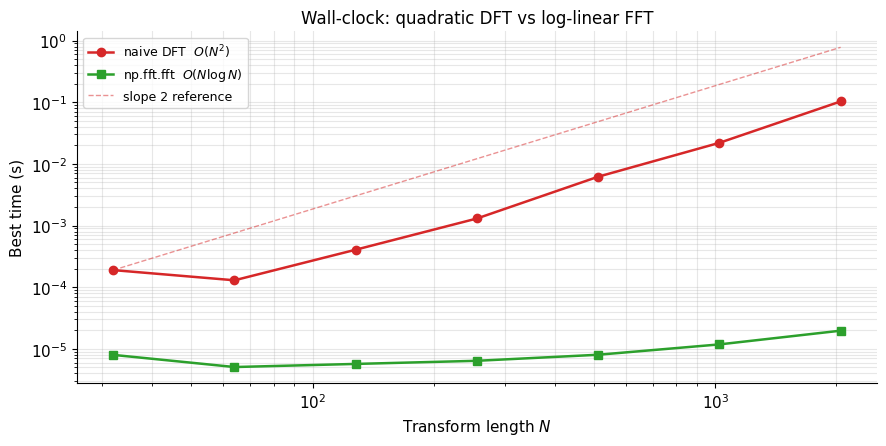

At N=2048: DFT 103.0 ms vs FFT 0.020 ms  →  5214x faster


In [8]:
import time

def time_call(fn, x, repeats=3):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); fn(x); best = min(best, time.perf_counter() - t0)
    return best

Ns = [2 ** p for p in range(5, 12)]           # 32 ... 2048
t_dft, t_fft = [], []
for N in Ns:
    x = np.random.default_rng(N).standard_normal(N)
    t_dft.append(time_call(dft_manual, x))
    t_fft.append(time_call(np.fft.fft, x))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.loglog(Ns, t_dft, 'o-', color=C_RE, lw=1.8, label='naive DFT  $O(N^2)$')
ax.loglog(Ns, t_fft, 's-', color=C_IM, lw=1.8, label='np.fft.fft  $O(N\\log N)$')
ref = np.array(Ns, float)
ax.loglog(Ns, t_dft[0] * (ref / ref[0]) ** 2, '--', color=C_RE,
          lw=1, alpha=0.5, label='slope 2 reference')
ax.set_xlabel('Transform length $N$'); ax.set_ylabel('Best time (s)')
ax.set_title('Wall-clock: quadratic DFT vs log-linear FFT')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'At N={Ns[-1]}: DFT {t_dft[-1]*1e3:.1f} ms vs FFT {t_fft[-1]*1e3:.3f} ms'
      f'  →  {t_dft[-1]/t_fft[-1]:.0f}x faster')